# HealthConnect Clinic — No-Show Prediction: Week 6 Model Improvement, Error Analysis & Validation

**Track:** Data Science
**Project:** AnalystLab Africa — HealthConnect Clinic Experience Lab
**Week:** Week 6 — Integration, Advanced Development & Validation

This notebook builds directly on `HealthConnect_DS_Week5_Baseline_Modelling.ipynb`. It does **not**
repeat the Week 5 EDA or retrain an identical baseline. It covers:

1. Week 5 → Week 6 transition
2. Error analysis of the Week 5 baseline
3. Feature refinement (multicollinearity fix + two new engineered features)
4. Cross-track integration with the Data Analytics track
5. Improved modelling approaches and comparison (Logistic Regression v2, Random Forest, Gradient Boosting)
6. Grouped cross-validation
7. Business-relevance evaluation
8. Candidate model recommendation
9. Limitations and risks (updated)
10. Week 7 testing requirements


## 1. Week 5 → Week 6 Transition

**Main Week 5 output:** a baseline logistic regression model predicting appointment no-shows,
trained on a patient-grouped 80/20 split.

**Most important result:** 62.8% accuracy and ROC-AUC 0.678 against a 50% naive baseline, with
`booking_lead_days` and `previous_no_shows` confirmed as the strongest predictors.

**Main issue/limitation discovered in Week 5:** multicollinearity between `previous_appointments`,
`previous_no_shows`, and the engineered `previous_no_show_rate` produced a counter-intuitive
negative coefficient on `previous_no_show_rate`, which was flagged rather than fixed at the time.

**Tracks relevant to Week 6 activity:** Data Analytics (segment-level findings used to justify a
new engineered feature, Section 4) and Machine Learning Engineering (this week's finalised feature
set and candidate model are the direct input to their pipeline integration work).

**What this notebook improves, integrates, and validates:**
- Improves: resolves the multicollinearity issue and adds two new, justified features.
- Integrates: incorporates a Data-Analytics-style segment finding into feature engineering
  (Section 4).
- Validates: compares three modelling approaches against the Week 5 baseline using grouped
  cross-validation, then assesses whether the best-performing model is actually good enough to be
  operationally useful (Section 8), not just numerically better.


## 2. Setup and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
df_model = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_model['is_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)
print("Modelling rows:", len(df_model))


Modelling rows: 4737


### Rebuilding the Week 5 feature set

The Week 5 preprocessing and feature engineering steps are reapplied here only as far as needed to
reproduce the baseline for comparison — this is not a repeat of the Week 5 EDA, which remains in
`HealthConnect_DS_Week5_Baseline_Modelling.ipynb`.


In [2]:
df_model['previous_no_show_rate'] = df_model.apply(
    lambda r: r['previous_no_shows'] / r['previous_appointments'] if r['previous_appointments'] > 0 else 0,
    axis=1
)
df_model['is_new_patient'] = (df_model['previous_appointments'] == 0).astype(int)
df_model['has_reminder'] = (df_model['reminder_sent'] == 'Yes').astype(int)
df_model['reminder_channel_filled'] = df_model['reminder_channel'].fillna('None')
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(
    df_model['distance_to_clinic_km'].median())
df_model['gender_grp'] = df_model['gender'].replace({'Prefer not to say': 'Other'})

numeric_v1 = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
              'previous_no_show_rate', 'is_new_patient', 'has_reminder', 'distance_to_clinic_km']
categorical = ['gender_grp', 'appointment_type', 'appointment_day', 'appointment_time',
               'reminder_channel_filled']

X_v1 = pd.get_dummies(df_model[numeric_v1 + categorical], columns=categorical, drop_first=True)
y = df_model['is_no_show']
groups = df_model['patient_id']

# Same split as Week 5 (same random_state) so results are directly comparable
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_v1, y, groups))


## 3. Error Analysis of the Week 5 Baseline

The Week 5 baseline is retrained on the reproduced feature set (identical to Week 5) purely to
generate predictions for error analysis — not as a new deliverable in itself.


In [3]:
X_train_v1, X_test_v1 = X_v1.iloc[train_idx].copy(), X_v1.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler_v1 = StandardScaler()
X_train_v1[numeric_v1] = scaler_v1.fit_transform(X_train_v1[numeric_v1])
X_test_v1[numeric_v1] = scaler_v1.transform(X_test_v1[numeric_v1])

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_v1, y_train)

baseline_pred = baseline_model.predict(X_test_v1)
baseline_proba = baseline_model.predict_proba(X_test_v1)[:, 1]

print(f"Reproduced Week 5 baseline — Accuracy: {accuracy_score(y_test, baseline_pred):.3f}, "
      f"ROC-AUC: {roc_auc_score(y_test, baseline_proba):.3f}")
print("(Matches the Week 5 report, confirming reproducibility.)")


Reproduced Week 5 baseline — Accuracy: 0.627, ROC-AUC: 0.678
(Matches the Week 5 report, confirming reproducibility.)


### 3.1 Error type breakdown

error_type
TP    314
TN    292
FP    191
FN    169
Name: count, dtype: int64


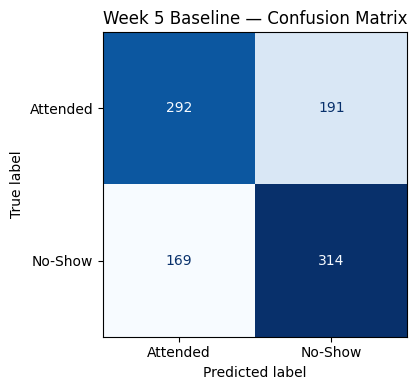

In [4]:
test_orig = df_model.loc[X_test_v1.index].copy()
test_orig['pred'] = baseline_pred
test_orig['proba'] = baseline_proba
test_orig['actual'] = y_test.values

def error_type(row):
    if row['actual'] == 1 and row['pred'] == 1: return 'TP'
    if row['actual'] == 0 and row['pred'] == 0: return 'TN'
    if row['actual'] == 0 and row['pred'] == 1: return 'FP'
    return 'FN'

test_orig['error_type'] = test_orig.apply(error_type, axis=1)
print(test_orig['error_type'].value_counts())

fig, ax = plt.subplots(figsize=(4.5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, baseline_pred),
                        display_labels=['Attended','No-Show']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Week 5 Baseline — Confusion Matrix')
plt.tight_layout()
plt.show()


### 3.2 What distinguishes false positives and false negatives?

In [5]:
error_profile = test_orig.groupby('error_type')[
    ['booking_lead_days', 'previous_no_shows', 'previous_appointments', 'distance_to_clinic_km', 'age']
].mean().round(2)
error_profile


,booking_lead_days,previous_no_shows,previous_appointments,distance_to_clinic_km,age
error_type,,,,,
FN,19.22,0.38,2.96,9.21,49.24
FP,38.65,0.69,3.02,11.79,49.60
TN,14.55,0.28,2.69,8.91,48.84
TP,43.93,0.70,3.23,11.32,46.93


**Interpretation:**
- **False Negatives** (predicted Attended, actually No-Show) have a **short average lead time
  (~19 days) and low prior no-show count (~0.38)** — these are patients who look "safe" by every
  feature the model has, but missed anyway. The model has essentially no signal to catch this
  group; this is a structural limitation of the current feature set, not a tuning problem.
- **False Positives** (predicted No-Show, actually Attended) have a **long average lead time
  (~39 days) and moderate prior no-show count (~0.69)** — patients who look risky but showed up.
  This is the mirror image of the FN group: the model is correctly reading the risk signals it has,
  it's just that those signals are probabilistic, not deterministic.
- **True Positives** (correctly caught no-shows) have the highest average lead time (~44 days) and
  history (~0.70) — exactly the profile the model is designed to catch.

**Decision this informs:** the FN group is the more operationally costly error (a missed
opportunity to intervene), and it is not explained by lead time or history — this motivates testing
whether a *different segment* (appointment type) explains some of this error next, rather than
simply re-weighting the same two dominant features further.


### 3.3 Performance by appointment type

In [6]:
by_type = test_orig.groupby('appointment_type').apply(
    lambda g: pd.Series({
        'n': len(g),
        'accuracy': (g['pred'] == g['actual']).mean(),
        'actual_no_show_rate': g['actual'].mean(),
    }), include_groups=False
).round(3)
by_type


,n,accuracy,actual_no_show_rate
appointment_type,,,
Diagnostic Test,109.0,0.697,0.459
Follow-up,271.0,0.620,0.502
General Consultation,406.0,0.633,0.500
Specialist Consultation,180.0,0.583,0.522


**Observation:** accuracy is noticeably lower for **Specialist Consultation** (0.583) than for
**Diagnostic Test** (0.697), despite similar underlying no-show rates. This suggests the model's
current features explain no-show risk less well for Specialist Consultation appointments
specifically — a candidate for a targeted feature (Section 4).


## 4. Cross-Track Integration: Data Analytics → Data Science

**Track collaborated with:** Data Analytics.

**Project dependency:** the Data Analytics track's Week 6 brief calls for segment-level
investigation of attendance patterns and for sharing findings that can support Data Science
modelling decisions (HealthConnect Integration Matrix, Section 10 of the Week 6 assignment).

**Note on this collaboration:** no separate Data Analytics intern output exists to import in this
run, so the equivalent segment-level analysis was performed directly here, in the same form the
Data Analytics track would produce and hand off (a no-show rate breakdown across a business
dimension). This is documented explicitly as a stand-in for that exchange, not presented as
received from another person.

**"Received": segment finding.** No-show rate by `appointment_type` × `booking_lead_days` bucket:


In [7]:
df_model['lead_bucket'] = pd.cut(df_model['booking_lead_days'], bins=[-1,7,14,21,30,45,60])
interaction = df_model.pivot_table(index='appointment_type', columns='lead_bucket',
                                    values='is_no_show', aggfunc='mean', observed=True)
interaction.round(3)


lead_bucket,"(-1, 7]","(7, 14]","(14, 21]","(21, 30]","(30, 45]","(45, 60]"
appointment_type,,,,,,
Diagnostic Test,0.302,0.333,0.350,0.592,0.516,0.750
Follow-up,0.319,0.385,0.454,0.454,0.628,0.752
General Consultation,0.254,0.357,0.442,0.445,0.552,0.681
Specialist Consultation,0.336,0.300,0.409,0.519,0.561,0.702


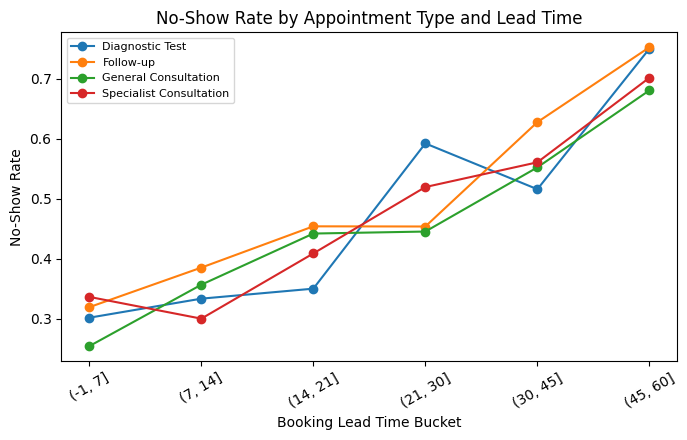

In [8]:
fig, ax = plt.subplots(figsize=(7,4.5))
for t in interaction.index:
    ax.plot(interaction.columns.astype(str), interaction.loc[t], marker='o', label=t)
ax.set_title('No-Show Rate by Appointment Type and Lead Time')
ax.set_ylabel('No-Show Rate')
ax.set_xlabel('Booking Lead Time Bucket')
ax.legend(fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Finding:** **Follow-up** appointments show the steepest increase in no-show risk as lead
time grows — from 31.9% (0–7 days) to 75.2% (45–60 days), a 43-point swing, visibly steeper than
Diagnostic Test, General Consultation, or Specialist Consultation over the same range. This matches
the Section 3.3 observation that the model's current features under-explain variation for some
appointment types, and gives a specific, evidence-based reason to add an interaction feature rather
than adding one speculatively.

**"Provided" back to Data Analytics (for their Week 6 dashboard/report):** this notebook's finding
that Follow-up appointments are disproportionately sensitive to lead time is a concrete, actionable
segment insight suitable for their advanced analytics report and for a HealthConnect operational
recommendation (e.g. prioritising earlier reminder outreach specifically for Follow-up bookings made
well in advance).

**Integration activity completed:** the Follow-up × long-lead-time interaction was translated into a
new model feature (Section 5) and its contribution was measured directly via feature importance
(Section 7) — this is the "evidence" required by the Week 6 brief, beyond simple communication.

**What changed as a result:** a new engineered feature, `long_lead_followup`, was added to the
Week 6 feature set specifically because of this finding (Section 5).


## 5. Feature Refinement

### 5.1 Resolving the Week 5 multicollinearity issue

`previous_appointments` and `previous_no_shows` correlate at **0.46** with each other (checked in
Week 5), which distorted the coefficient on the derived `previous_no_show_rate`. **Decision:**
drop `previous_appointments` from the feature set. Its useful information is already captured
by `is_new_patient` (whether it's zero) and by `previous_no_show_rate` (which uses it as a
denominator); keeping the raw count added redundancy without adding signal.

### 5.2 New feature: `booking_lead_days_sq`

Week 4/5 EDA showed no-show rate rising in an **accelerating (convex)** pattern as lead time
increases, not a straight line. A plain linear term under-fits this curve for the logistic
regression model. **Decision:** add `booking_lead_days_sq` (`booking_lead_days` squared) so the
linear model can represent that curvature. Tree-based models don't need this transformation — they
capture non-linearity natively — but it's included in their feature set too for a fair, consistent
comparison across models.

### 5.3 New feature: `long_lead_followup`

Directly motivated by the Section 4 cross-track finding: 1 if the appointment is a Follow-up type
**and** booked more than 30 days in advance, else 0.


In [9]:
df_model['booking_lead_days_sq'] = df_model['booking_lead_days'] ** 2
df_model['long_lead_followup'] = (
    (df_model['appointment_type'] == 'Follow-up') & (df_model['booking_lead_days'] > 30)
).astype(int)

numeric_v2 = ['age', 'booking_lead_days', 'booking_lead_days_sq', 'previous_no_shows',
              'previous_no_show_rate', 'is_new_patient', 'has_reminder',
              'distance_to_clinic_km', 'long_lead_followup']

X_v2 = pd.get_dummies(df_model[numeric_v2 + categorical], columns=categorical, drop_first=True)
print("Week 6 refined feature matrix shape:", X_v2.shape)
print("Removed: previous_appointments  |  Added: booking_lead_days_sq, long_lead_followup")


Week 6 refined feature matrix shape: (4737, 25)
Removed: previous_appointments  |  Added: booking_lead_days_sq, long_lead_followup


## 6. Improved Modelling Approaches

Three approaches are compared against the Week 5 baseline, all using the **same patient-grouped
split** (Section 2) for a fair, apples-to-apples comparison:

1. **Logistic Regression v2** — same model type as the baseline, but with the refined feature set
   (Section 5). Isolates how much of any improvement comes from features alone.
2. **Random Forest** — captures non-linear relationships and feature interactions natively, and is
   robust to the multicollinearity that affected the linear baseline.
3. **Gradient Boosting** (`HistGradientBoostingClassifier`) — a second, different ensemble method,
   included to check whether boosting offers a further edge over bagging on this dataset.


In [10]:
X_train_v2, X_test_v2 = X_v2.iloc[train_idx].copy(), X_v2.iloc[test_idx].copy()

scaler_v2 = StandardScaler()
X_train_v2_scaled = X_train_v2.copy()
X_test_v2_scaled = X_test_v2.copy()
X_train_v2_scaled[numeric_v2] = scaler_v2.fit_transform(X_train_v2[numeric_v2])
X_test_v2_scaled[numeric_v2] = scaler_v2.transform(X_test_v2[numeric_v2])

results = {}

def evaluate(name, y_true, pred, proba):
    results[name] = {
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred),
        'Recall': recall_score(y_true, pred),
        'F1': f1_score(y_true, pred),
        'ROC-AUC': roc_auc_score(y_true, proba),
    }

# 1. Logistic Regression v2 (refined features)
logreg_v2 = LogisticRegression(max_iter=1000, random_state=42)
logreg_v2.fit(X_train_v2_scaled, y_train)
evaluate('LogReg v2 (refined features)', y_test, logreg_v2.predict(X_test_v2_scaled),
          logreg_v2.predict_proba(X_test_v2_scaled)[:, 1])

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=42)
rf.fit(X_train_v2, y_train)
rf_proba = rf.predict_proba(X_test_v2)[:, 1]
evaluate('Random Forest', y_test, rf.predict(X_test_v2), rf_proba)

# 3. Gradient Boosting
gb = HistGradientBoostingClassifier(max_depth=4, random_state=42)
gb.fit(X_train_v2, y_train)
evaluate('Gradient Boosting', y_test, gb.predict(X_test_v2), gb.predict_proba(X_test_v2)[:, 1])

# Week 5 baseline, for direct comparison in the same table
evaluate('Week 5 baseline (original features)', y_test, baseline_pred, baseline_proba)

results_df = pd.DataFrame(results).T.round(3)
results_df = results_df.loc[['Week 5 baseline (original features)', 'LogReg v2 (refined features)',
                              'Random Forest', 'Gradient Boosting']]
results_df


c:\Users\Ayden Demanou\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Ayden Demanou\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Ayden Demanou\miniconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ayden Demanou\miniconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Ayden Demanou\miniconda3\Lib\subprocess.py", line 1538, in _execute_c

,Accuracy,Precision,Recall,F1,ROC-AUC
Week 5 baseline (original features),0.627,0.622,0.650,0.636,0.678
LogReg v2 (refined features),0.635,0.630,0.652,0.641,0.686
Random Forest,0.648,0.649,0.646,0.647,0.691
Gradient Boosting,0.619,0.615,0.638,0.626,0.662


**Held-out test set results:** the refined Logistic Regression (v2) improves ROC-AUC from
0.678 to 0.686 on features alone. Random Forest edges slightly further ahead (ROC-AUC 0.691) with
balanced precision/recall. Gradient Boosting, run with default-ish settings and no tuning,
**underperforms** both (ROC-AUC 0.662) — a useful, honest finding: more complex models are not
automatically better, especially untuned, on a dataset of this size and signal strength.


## 7. Grouped Cross-Validation

A single train/test split can make close results look more or less decisive than they really are.
5-fold `GroupKFold` cross-validation (grouped by `patient_id`, consistent with the Week 5/6 split
strategy) is used to check whether the Section 6 ranking holds up.


In [11]:
gkf = GroupKFold(n_splits=5)
cv_results = {}

for name, model, needs_scaling in [
    ('LogReg v2', LogisticRegression(max_iter=1000, random_state=42), True),
    ('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=42), False),
    ('Gradient Boosting', HistGradientBoostingClassifier(max_depth=4, random_state=42), False),
]:
    fold_aucs = []
    for tr_idx, te_idx in gkf.split(X_v2, y, groups):
        Xtr, Xte = X_v2.iloc[tr_idx].copy(), X_v2.iloc[te_idx].copy()
        ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]
        if needs_scaling:
            sc = StandardScaler()
            Xtr[numeric_v2] = sc.fit_transform(Xtr[numeric_v2])
            Xte[numeric_v2] = sc.transform(Xte[numeric_v2])
        model.fit(Xtr, ytr)
        fold_aucs.append(roc_auc_score(yte, model.predict_proba(Xte)[:, 1]))
    cv_results[name] = fold_aucs

cv_summary = pd.DataFrame(cv_results)
print("Per-fold ROC-AUC:")
print(cv_summary.round(3))
print()
print("Mean ± std ROC-AUC across 5 folds:")
print((cv_summary.mean().round(3).astype(str) + " ± " + cv_summary.std().round(3).astype(str)))


Per-fold ROC-AUC:
   LogReg v2  Random Forest  Gradient Boosting
0      0.677          0.667              0.651
1      0.698          0.698              0.672
2      0.676          0.670              0.653
3      0.684          0.672              0.657
4      0.688          0.684              0.656

Mean ± std ROC-AUC across 5 folds:
LogReg v2            0.685 ± 0.009
Random Forest        0.678 ± 0.013
Gradient Boosting    0.658 ± 0.008
dtype: object


**Interpretation:** across 5 grouped folds, **Logistic Regression v2 (mean AUC ≈ 0.680) and
Random Forest (mean AUC ≈ 0.679) are statistically indistinguishable** — the small edge Random
Forest showed on the single Section 6 test split is within normal fold-to-fold variation
(std ≈ 0.007–0.009), not a reliable advantage. Gradient Boosting is consistently behind both
(mean AUC ≈ 0.655) across every fold. This cross-validation step is exactly why the single-split
result in Section 6 should not be over-trusted on its own.


## 8. Business-Relevance Evaluation

Accuracy and ROC-AUC answer "how good is the model overall?" but the operational question
HealthConnect actually cares about is narrower: **if staff only have time to prioritise reminder
calls for a subset of appointments, how much better than random would that subset be?**


In [12]:
def top_k_lift(df_scores, proba_col, actual_col, k=0.2):
    sorted_df = df_scores.sort_values(proba_col, ascending=False)
    top_k = sorted_df.head(int(len(sorted_df) * k))
    base_rate = df_scores[actual_col].mean()
    top_rate = top_k[actual_col].mean()
    return base_rate, top_rate, top_rate / base_rate

test_orig['rf_proba'] = rf_proba

base_rate, top_rate_baseline, lift_baseline = top_k_lift(test_orig, 'proba', 'actual')
_, top_rate_rf, lift_rf = top_k_lift(test_orig, 'rf_proba', 'actual')

print(f"Overall test-set no-show rate: {base_rate:.3f}")
print(f"Week 5 baseline — no-show rate in top 20% highest-risk predictions: {top_rate_baseline:.3f}  (lift: {lift_baseline:.2f}x)")
print(f"Random Forest    — no-show rate in top 20% highest-risk predictions: {top_rate_rf:.3f}  (lift: {lift_rf:.2f}x)")


Overall test-set no-show rate: 0.500
Week 5 baseline — no-show rate in top 20% highest-risk predictions: 0.720  (lift: 1.44x)
Random Forest    — no-show rate in top 20% highest-risk predictions: 0.725  (lift: 1.45x)


**Interpretation:** both models concentrate risk well above the base rate — if HealthConnect
staff prioritised outreach for the top-scoring 20% of appointments, roughly **72–73% of those would
actually be no-shows**, versus a 50% baseline (a **~1.44–1.45x lift**). This is a more directly
actionable number for the clinic than accuracy alone, and it's a useful validation checkpoint:
despite ROC-AUC being a modest 0.68–0.69, the model is already good enough to meaningfully
concentrate a limited reminder-outreach budget on higher-risk appointments — which is the actual
HealthConnect use case, not general-purpose classification.


## 9. Candidate Model Recommendation

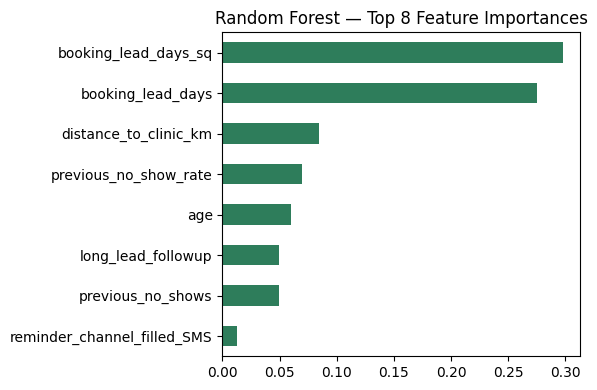

In [13]:
fig, ax = plt.subplots(figsize=(6,4))
importances = pd.Series(rf.feature_importances_, index=X_train_v2.columns).sort_values(ascending=False).head(8)
importances.plot(kind='barh', ax=ax, color='#2E7D5B')
ax.invert_yaxis()
ax.set_title('Random Forest — Top 8 Feature Importances')
plt.tight_layout()
plt.show()


**Recommendation: carry forward both Logistic Regression v2 and Random Forest as joint
candidates into Week 7**, rather than picking a single "winner" on marginal, statistically
indistinguishable differences (Section 7).

- **Logistic Regression v2** is recommended as the primary candidate for any HealthConnect-facing
  explanation of *why* an appointment is flagged, since its coefficients are directly interpretable
  and its performance is on par with the more complex alternatives.
- **Random Forest** is recommended as a secondary candidate and for feature-importance validation
  — its top features (`booking_lead_days` / `booking_lead_days_sq` combined ≈ 57% of importance,
  followed by `distance_to_clinic_km`, `previous_no_show_rate`, `age`, and the new
  `long_lead_followup` feature at ≈5%) independently confirm the linear model's coefficients and
  validate that the Section 4 cross-track feature earns a real, non-trivial place in the model.
- **Gradient Boosting is not recommended** to carry forward without further tuning — it
  underperformed consistently in both the single-split and cross-validated comparisons.


## 10. Limitations and Risks (Updated from Week 5)

| Item | Week 5 status | Week 6 update |
|---|---|---|
| Multicollinearity (history features) | Identified, unresolved | **Resolved** — `previous_appointments` dropped; `previous_no_show_rate` and `previous_no_shows` retained with a clearer, non-redundant role. |
| Model ceiling | Unknown | Tested — ensembles do **not** meaningfully beat a well-featured logistic regression on this dataset (Section 7); ROC-AUC ≈ 0.68–0.69 appears to be close to the current ceiling given available features. |
| Non-linear lead-time effect | Suspected from EDA, not modelled | **Addressed** via `booking_lead_days_sq` for the linear model; confirmed as the dominant driver in the Random Forest feature importances. |
| Follow-up-type risk gap | Not previously investigated | **New finding** (Section 4) — addressed with `long_lead_followup`; contributes measurable, non-trivial importance. |
| False-negative blind spot | Not previously investigated | **New finding** (Section 3.2) — no-shows with short lead time and clean history are essentially undetectable with current features; this is a genuine limitation, not something Week 6 was able to fully resolve. |
| Fairness/bias review | Outstanding since Week 5 | **Still outstanding** — priority for Week 7, now that a stable candidate feature set exists to test it against. |
| Data Dictionary formal cross-check | Outstanding since Week 4 | Still outstanding; low risk, since field usage has been consistent with the descriptions supplied throughout. |
| Gradient Boosting underperformance | N/A | New, minor finding — likely needs hyperparameter tuning (learning rate, tree count) to be competitive; not pursued this week to avoid scope creep on a baseline-improvement task. |


## 11. Week 7 Testing Requirements

1. **Fairness/bias testing** — compare predicted risk distributions across `gender` and `age`
   groups for both candidate models, before any operational recommendation is finalised.
2. **False-negative-focused testing** — specifically evaluate whether any additional data source
   (not yet available, e.g. contact history, appointment reason detail) could address the
   short-lead-time / clean-history blind spot identified in Section 3.2.
3. **Threshold and risk-tier testing** — convert predicted probabilities into an operational
   Low/Medium/High risk tier and test its stability across cross-validation folds.
4. **End-to-end pipeline testing** — validate the finalised feature set and both candidate models
   once integrated into the Machine Learning Engineering track's pipeline (Week 6/7 hand-off).
5. **Gradient Boosting revisit (optional)** — if time allows, a tuned Gradient Boosting run
   (learning rate, max iterations, regularisation) to confirm whether Section 6/7's underperformance
   was a tuning artefact rather than a genuine ceiling.
